# 신용카드사기탐지_모델만들기

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

In [84]:
data = pd.read_csv("./data/fraud.csv")
data.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [85]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 22 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   trans_date_trans_time  object 
 1   cc_num                 int64  
 2   merchant               object 
 3   category               object 
 4   amt                    float64
 5   first                  object 
 6   last                   object 
 7   gender                 object 
 8   street                 object 
 9   city                   object 
 10  state                  object 
 11  zip                    int64  
 12  lat                    float64
 13  long                   float64
 14  city_pop               int64  
 15  job                    object 
 16  dob                    object 
 17  trans_num              object 
 18  unix_time              int64  
 19  merch_lat              float64
 20  merch_long             float64
 21  is_fraud               int64  
dtypes: float64(5), int

In [86]:
data.describe()

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06
mean,4.173860e+17,7.006357e+01,4.881326e+04,3.853931e+01,-9.022783e+01,8.864367e+04,1.358674e+09,3.853898e+01,-9.022794e+01,5.210015e-03
std,1.309115e+18,1.592540e+02,2.688185e+04,5.071470e+00,1.374789e+01,3.014876e+05,1.819508e+07,5.105604e+00,1.375969e+01,7.199217e-02
min,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902742e+01,-1.666716e+02,0.000000e+00
25%,1.800429e+14,9.640000e+00,2.623700e+04,3.466890e+01,-9.679800e+01,7.410000e+02,1.343017e+09,3.474012e+01,-9.689944e+01,0.000000e+00
50%,3.521417e+15,4.745000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.443000e+03,1.357089e+09,3.936890e+01,-8.744069e+01,0.000000e+00
75%,4.642255e+15,8.310000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.374581e+09,4.195626e+01,-8.024511e+01,0.000000e+00
max,4.992346e+18,2.894890e+04,9.992100e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.388534e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [87]:
data.isna().sum()

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [88]:
obj_cols = data.select_dtypes(include="object")
num_cols = data.select_dtypes(exclude="object")

In [89]:
for col in obj_cols:
    print("="*30, col, "="*30)
    print("nunique: ", obj_cols[col].nunique())
    print(obj_cols[col].value_counts())
    
#     print(data[[col, 'is_fraud']].groupby(col).mean().sort_values(by='is_fraud', ascending=False))
    result = data[[col, 'is_fraud']].groupby(col).mean().sort_values(by='is_fraud', ascending=False)
    result = result[result['is_fraud'] > 0]
    print(result)

============================== trans_date_trans_time ==============================
nunique:  1819551
trans_date_trans_time
2019-04-22 16:02:01    4
2020-06-01 01:37:47    4
2020-06-02 12:47:07    4
2020-10-05 19:37:49    4
2020-12-13 17:53:47    4
                      ..
2019-01-01 00:20:15    1
2019-01-01 00:21:32    1
2019-01-01 00:22:06    1
2019-01-01 00:22:18    1
2019-01-01 00:00:44    1
Name: count, Length: 1819551, dtype: int64
                       is_fraud
trans_date_trans_time          
2019-09-11 22:58:11    1.000000
2019-12-22 01:09:30    1.000000
2019-02-12 23:49:17    1.000000
2019-09-23 06:33:47    1.000000
2019-05-03 04:38:52    1.000000
...                         ...
2020-07-21 23:49:05    0.333333
2020-09-27 15:13:13    0.333333
2020-10-12 22:31:39    0.333333
2019-08-03 22:42:34    0.333333
2020-06-15 22:03:50    0.333333

[9646 rows x 1 columns]
============================== merchant ==============================
nunique:  693
merchant
fraud_Kilback LLC      

                                is_fraud
job                                     
Air traffic controller          1.000000
Careers adviser                 1.000000
Broadcast journalist            1.000000
Armed forces technical officer  1.000000
Contracting civil engineer      1.000000
...                                  ...
Designer, furniture             0.001144
Designer, exhibition/display    0.000914
Statistician                    0.000823
Health physicist                0.000686
Contractor                      0.000458

[494 rows x 1 columns]
============================== dob ==============================
nunique:  984
dob
1977-03-23    8044
1988-09-15    6574
1981-08-29    6571
1955-05-06    5121
1960-01-13    4395
              ... 
1936-05-04       7
1964-09-17       7
1963-02-26       7
1999-10-26       7
1998-08-02       6
Name: count, Length: 984, dtype: int64
            is_fraud
dob                 
1927-02-03  1.000000
1932-08-10  1.000000
1932-05-09  1.000000
1931-0

============================== cc_num ==============================
count    1.852394e+06
mean     4.173860e+17
std      1.309115e+18
min      6.041621e+10
25%      1.800429e+14
50%      3.521417e+15
75%      4.642255e+15
max      4.992346e+18
Name: cc_num, dtype: float64
cc_num
30270432095985      4392
6538441737335434    4392
4642255475285942    4386
6538891242532018    4386
4364010865167176    4386
                    ... 
501894933032           7
4975457191020          7
6577777028615915       7
180097223252063        7
4295296907373          6
Name: count, Length: 999, dtype: int64


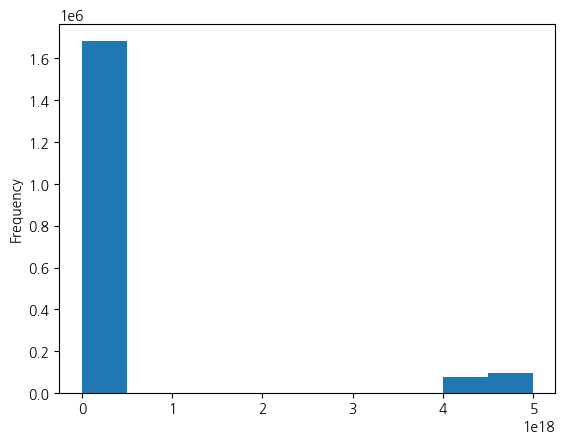

                     is_fraud
cc_num                       
4659625317833446364  1.000000
4714017207228610634  1.000000
6517779374888867     1.000000
5301645381939419     1.000000
503886119844         1.000000
...                       ...
4809701904914        0.000685
3518234918950662     0.000549
3576431665303017     0.000458
6011109736646996     0.000458
6011893664860915     0.000457

[976 rows x 1 columns]
============================== amt ==============================
count    1.852394e+06
mean     7.006357e+01
std      1.592540e+02
min      1.000000e+00
25%      9.640000e+00
50%      4.745000e+01
75%      8.310000e+01
max      2.894890e+04
Name: amt, dtype: float64
amt
1.14       779
1.10       745
1.04       744
1.08       741
1.25       737
          ... 
537.02       1
1309.21      1
850.87       1
516.74       1
540.49       1
Name: count, Length: 60616, dtype: int64


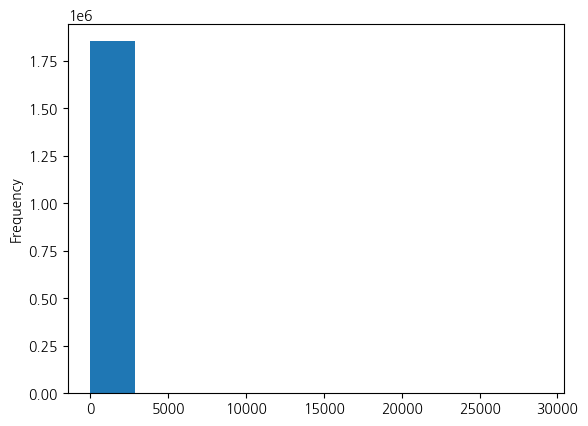

        is_fraud
amt             
281.28  1.000000
984.69  1.000000
984.59  1.000000
684.27  1.000000
277.20  1.000000
...          ...
2.25    0.001629
1.51    0.001580
1.78    0.001558
1.91    0.001558
1.06    0.001490

[8296 rows x 1 columns]
============================== zip ==============================
count    1.852394e+06
mean     4.881326e+04
std      2.688185e+04
min      1.257000e+03
25%      2.623700e+04
50%      4.817400e+04
75%      7.204200e+04
max      9.992100e+04
Name: zip, dtype: float64
zip
82514    5116
73754    5116
48088    5115
34112    5108
61454    4392
         ... 
61364       7
46510       7
37411       7
16041       7
52658       6
Name: count, Length: 985, dtype: int64


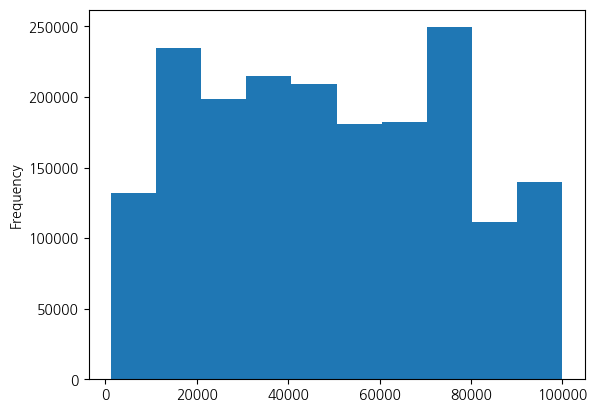

       is_fraud
zip            
99921  1.000000
66958  1.000000
62896  1.000000
65745  1.000000
68375  1.000000
...         ...
36869  0.000685
75092  0.000549
85020  0.000458
28405  0.000458
80120  0.000457

[963 rows x 1 columns]
============================== lat ==============================
count    1.852394e+06
mean     3.853931e+01
std      5.071470e+00
min      2.002710e+01
25%      3.466890e+01
50%      3.935430e+01
75%      4.194040e+01
max      6.669330e+01
Name: lat, dtype: float64
lat
43.0048    5116
36.3850    5116
42.5164    5115
26.1184    5108
41.3851    4392
           ... 
40.7547       7
36.8294       7
34.0066       7
41.1225       7
40.7067       6
Name: count, Length: 983, dtype: int64


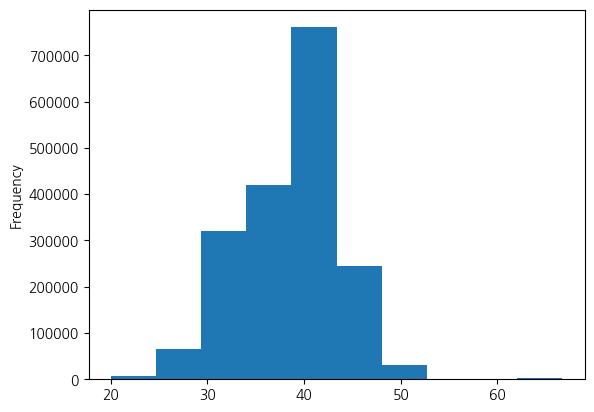

         is_fraud
lat              
47.6633  1.000000
66.6933  1.000000
27.8942  1.000000
47.5412  1.000000
36.7410  1.000000
...           ...
32.4204  0.000685
33.6372  0.000549
33.5623  0.000458
34.2651  0.000458
39.5994  0.000457

[961 rows x 1 columns]
============================== long ==============================
count    1.852394e+06
mean    -9.022783e+01
std      1.374789e+01
min     -1.656723e+02
25%     -9.679800e+01
50%     -8.747690e+01
75%     -8.015800e+01
max     -6.795030e+01
Name: long, dtype: float64
long
-108.8964    5116
-98.0727     5116
-82.9832     5115
-81.7361     5108
-91.0391     4392
             ... 
-95.4460        7
-73.9925        7
-85.2356        7
-76.2701        7
-91.2268        6
Name: count, Length: 983, dtype: int64


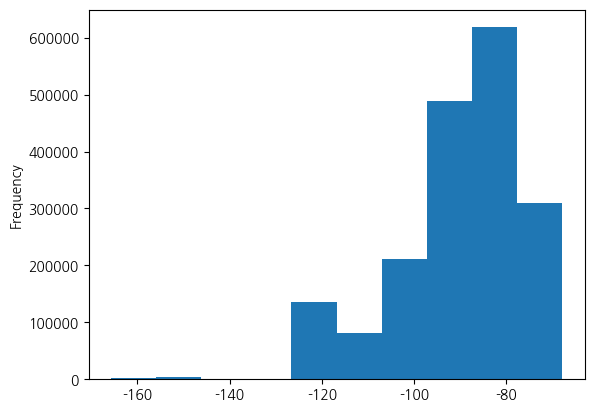

           is_fraud
long               
-133.1171  1.000000
-90.2848   1.000000
-120.1922  1.000000
-89.3484   1.000000
-90.1773   1.000000
...             ...
-85.0796   0.000685
-96.6184   0.000549
-112.0559  0.000458
-77.8670   0.000458
-105.0044  0.000457

[961 rows x 1 columns]
============================== city_pop ==============================
count    1.852394e+06
mean     8.864367e+04
std      3.014876e+05
min      2.300000e+01
25%      7.410000e+02
50%      2.443000e+03
75%      2.032800e+04
max      2.906700e+06
Name: city_pop, dtype: float64
city_pop
606        8049
1595797    7312
1312922    7297
241        6578
1766       6556
           ... 
99475         7
3631          7
198659        7
242803        7
1071          6
Name: count, Length: 891, dtype: int64


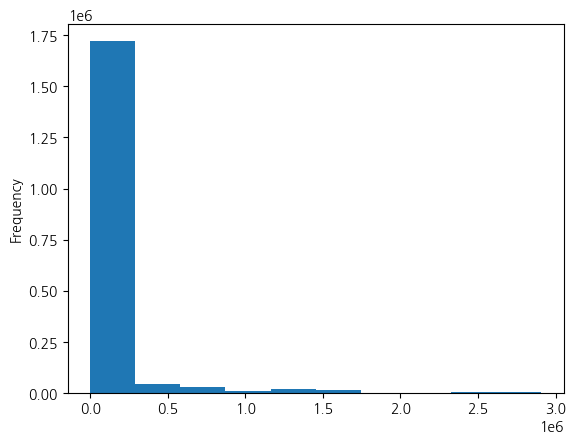

          is_fraud
city_pop          
7322      1.000000
7339      1.000000
7332      1.000000
7369      1.000000
7511      1.000000
...            ...
34882     0.000686
5875      0.000686
59744     0.000685
46563     0.000549
320420    0.000457

[873 rows x 1 columns]
============================== unix_time ==============================
count    1.852394e+06
mean     1.358674e+09
std      1.819508e+07
min      1.325376e+09
25%      1.343017e+09
50%      1.357089e+09
75%      1.374581e+09
max      1.388534e+09
Name: unix_time, dtype: float64
unix_time
1335110521    4
1370050667    4
1370177227    4
1381001869    4
1386957227    4
             ..
1325377215    1
1325377292    1
1325377326    1
1325377338    1
1325376044    1
Name: count, Length: 1819583, dtype: int64


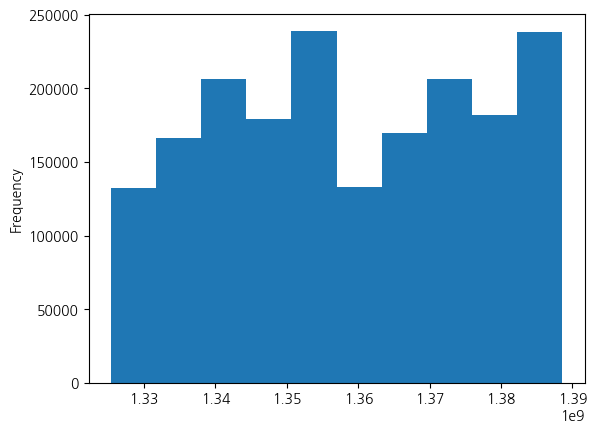

            is_fraud
unix_time           
1341538357  1.000000
1344862776  1.000000
1329090557  1.000000
1354665315  1.000000
1350857340  1.000000
...              ...
1374450545  0.333333
1344033754  0.333333
1380294793  0.333333
1371333830  0.333333
1381617099  0.333333

[9646 rows x 1 columns]
============================== merch_lat ==============================
count    1.852394e+06
mean     3.853898e+01
std      5.105604e+00
min      1.902742e+01
25%      3.474012e+01
50%      3.936890e+01
75%      4.195626e+01
max      6.751027e+01
Name: merch_lat, dtype: float64
merch_lat
39.545984    4
41.014694    4
40.016559    4
41.973278    4
39.516582    4
            ..
37.980931    1
43.987649    1
19.560013    1
38.742490    1
27.630593    1
Name: count, Length: 1754157, dtype: int64


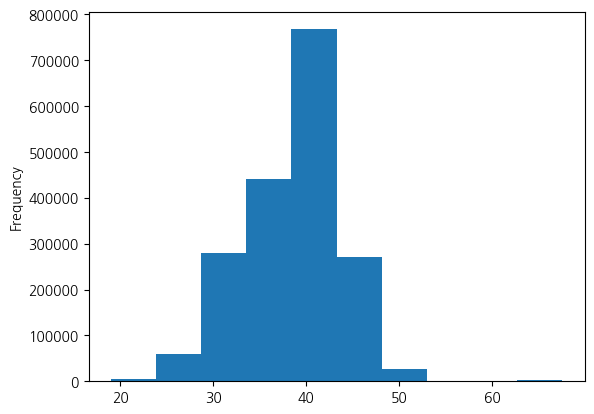

           is_fraud
merch_lat          
38.809769  1.000000
67.510267  1.000000
27.576053  1.000000
34.739887  1.000000
38.449115  1.000000
...             ...
40.552978  0.333333
40.358112  0.333333
38.447981  0.250000
41.308247  0.250000
41.204635  0.250000

[9649 rows x 1 columns]
============================== merch_long ==============================
count    1.852394e+06
mean    -9.022794e+01
std      1.375969e+01
min     -1.666716e+02
25%     -9.689944e+01
50%     -8.744069e+01
75%     -8.024511e+01
max     -6.695090e+01
Name: merch_long, dtype: float64
merch_long
-92.521318    4
-87.830842    4
-82.223196    4
-81.219189    4
-74.433003    4
             ..
-71.217297    1
-91.955115    1
-91.272903    1
-98.610225    1
-78.632459    1
Name: count, Length: 1809753, dtype: int64


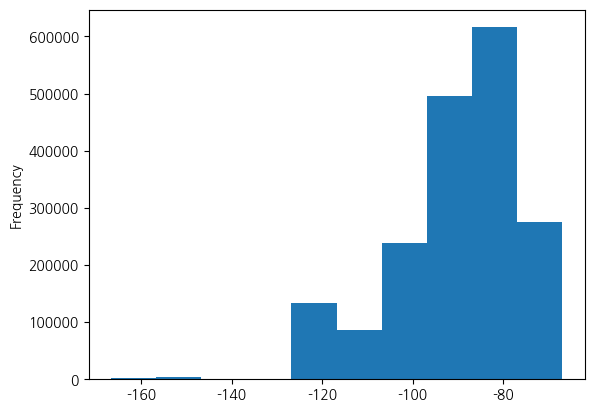

             is_fraud
merch_long           
-95.687871   1.000000
-89.176591   1.000000
-103.432490  1.000000
-87.651246   1.000000
-97.675129   1.000000
...               ...
-73.790264   0.333333
-77.753339   0.333333
-75.336649   0.333333
-84.905514   0.333333
-81.178745   0.333333

[9649 rows x 1 columns]


In [90]:
for col in num_cols.iloc[:,:-1]:
    print("="*30, col, "="*30)
    print(num_cols[col].describe())
    print(num_cols[col].value_counts())
    num_cols[col].plot(kind='hist')
    plt.show()
    
#     print(data[[col, 'is_fraud']].groupby(col).mean().sort_values(by='is_fraud', ascending=False))
    result = data[[col, 'is_fraud']].groupby(col).mean().sort_values(by='is_fraud', ascending=False)
    result = result[result['is_fraud'] > 0]
    print(result)

In [91]:
num_cols.columns

Index(['cc_num', 'amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

<Axes: ylabel='amt'>

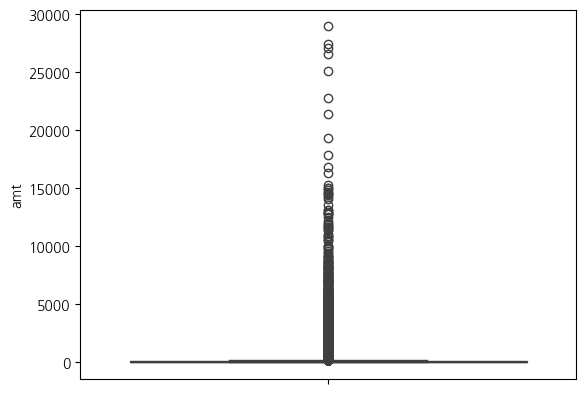

In [92]:
sns.boxplot(num_cols['amt'])

데이터 타입 변환

In [93]:
data.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud'],
      dtype='object')

In [94]:
# trans_date_trans_time컬럼을 날짜 타입으로 변환
data['trans_date_trans_time'] = pd.to_datetime(data['trans_date_trans_time'])

In [95]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 22 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   trans_date_trans_time  datetime64[ns]
 1   cc_num                 int64         
 2   merchant               object        
 3   category               object        
 4   amt                    float64       
 5   first                  object        
 6   last                   object        
 7   gender                 object        
 8   street                 object        
 9   city                   object        
 10  state                  object        
 11  zip                    int64         
 12  lat                    float64       
 13  long                   float64       
 14  city_pop               int64         
 15  job                    object        
 16  dob                    object        
 17  trans_num              object        
 18  unix_time             

In [96]:
# 데이터는 많지만 실제 고객 수는 999명
data['cc_num'].nunique()

999

In [97]:
data[data['street'] == "994 Grant Mall"]

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
683413,2019-10-19 00:30:18,676327197445,"fraud_Goldner, Kovacek and Abbott",grocery_pos,294.00,Benjamin,Beck,M,994 Grant Mall,Irvington,...,41.0381,-73.8597,7322,Air traffic controller,1948-05-16,8fb049c38ad1dbebad0301e2cda747a5,1350606618,41.906364,-73.980128,1
683471,2019-10-19 01:03:16,676327197445,"fraud_Christiansen, Goyette and Schamberger",gas_transport,9.98,Benjamin,Beck,M,994 Grant Mall,Irvington,...,41.0381,-73.8597,7322,Air traffic controller,1948-05-16,28c4374a563405f8867f26de47bf3964,1350608596,40.152782,-74.044250,1
685812,2019-10-19 22:26:18,676327197445,"fraud_Gottlieb, Considine and Schultz",shopping_net,995.57,Benjamin,Beck,M,994 Grant Mall,Irvington,...,41.0381,-73.8597,7322,Air traffic controller,1948-05-16,ea3bebf0f405ff26786e0e52918d8f31,1350685578,41.189389,-73.105949,1
686002,2019-10-19 23:45:15,676327197445,"fraud_Altenwerth, Cartwright and Koss",shopping_net,1091.61,Benjamin,Beck,M,994 Grant Mall,Irvington,...,41.0381,-73.8597,7322,Air traffic controller,1948-05-16,a6f64811491f1c976ad9bed61398c4d3,1350690315,40.619197,-74.626533,1
688955,2019-10-20 22:10:00,676327197445,fraud_Boyer-Reichert,shopping_net,1000.46,Benjamin,Beck,M,994 Grant Mall,Irvington,...,41.0381,-73.8597,7322,Air traffic controller,1948-05-16,391bd0d97cf13bc6384f9e5dbc5554a2,1350771000,41.687578,-73.113944,1
689055,2019-10-20 22:47:05,676327197445,"fraud_Towne, Greenholt and Koepp",shopping_net,911.61,Benjamin,Beck,M,994 Grant Mall,Irvington,...,41.0381,-73.8597,7322,Air traffic controller,1948-05-16,acbabdfb4548f427cecff8ebf5286eb7,1350773225,40.877696,-73.998720,1
689062,2019-10-20 22:48:05,676327197445,"fraud_Heathcote, Yost and Kertzmann",shopping_net,1018.86,Benjamin,Beck,M,994 Grant Mall,Irvington,...,41.0381,-73.8597,7322,Air traffic controller,1948-05-16,e2fcacb12c06c50292c5529fe0bf39e1,1350773285,40.339684,-73.692390,1
689191,2019-10-20 23:37:15,676327197445,fraud_Corwin-Gorczany,misc_net,875.86,Benjamin,Beck,M,994 Grant Mall,Irvington,...,41.0381,-73.8597,7322,Air traffic controller,1948-05-16,75c05ab117f96a4d688038344323ca55,1350776235,40.229840,-74.130332,1


In [98]:
data[data['cc_num'] == 676327197445]

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
683413,2019-10-19 00:30:18,676327197445,"fraud_Goldner, Kovacek and Abbott",grocery_pos,294.00,Benjamin,Beck,M,994 Grant Mall,Irvington,...,41.0381,-73.8597,7322,Air traffic controller,1948-05-16,8fb049c38ad1dbebad0301e2cda747a5,1350606618,41.906364,-73.980128,1
683471,2019-10-19 01:03:16,676327197445,"fraud_Christiansen, Goyette and Schamberger",gas_transport,9.98,Benjamin,Beck,M,994 Grant Mall,Irvington,...,41.0381,-73.8597,7322,Air traffic controller,1948-05-16,28c4374a563405f8867f26de47bf3964,1350608596,40.152782,-74.044250,1
685812,2019-10-19 22:26:18,676327197445,"fraud_Gottlieb, Considine and Schultz",shopping_net,995.57,Benjamin,Beck,M,994 Grant Mall,Irvington,...,41.0381,-73.8597,7322,Air traffic controller,1948-05-16,ea3bebf0f405ff26786e0e52918d8f31,1350685578,41.189389,-73.105949,1
686002,2019-10-19 23:45:15,676327197445,"fraud_Altenwerth, Cartwright and Koss",shopping_net,1091.61,Benjamin,Beck,M,994 Grant Mall,Irvington,...,41.0381,-73.8597,7322,Air traffic controller,1948-05-16,a6f64811491f1c976ad9bed61398c4d3,1350690315,40.619197,-74.626533,1
688955,2019-10-20 22:10:00,676327197445,fraud_Boyer-Reichert,shopping_net,1000.46,Benjamin,Beck,M,994 Grant Mall,Irvington,...,41.0381,-73.8597,7322,Air traffic controller,1948-05-16,391bd0d97cf13bc6384f9e5dbc5554a2,1350771000,41.687578,-73.113944,1
689055,2019-10-20 22:47:05,676327197445,"fraud_Towne, Greenholt and Koepp",shopping_net,911.61,Benjamin,Beck,M,994 Grant Mall,Irvington,...,41.0381,-73.8597,7322,Air traffic controller,1948-05-16,acbabdfb4548f427cecff8ebf5286eb7,1350773225,40.877696,-73.998720,1
689062,2019-10-20 22:48:05,676327197445,"fraud_Heathcote, Yost and Kertzmann",shopping_net,1018.86,Benjamin,Beck,M,994 Grant Mall,Irvington,...,41.0381,-73.8597,7322,Air traffic controller,1948-05-16,e2fcacb12c06c50292c5529fe0bf39e1,1350773285,40.339684,-73.692390,1
689191,2019-10-20 23:37:15,676327197445,fraud_Corwin-Gorczany,misc_net,875.86,Benjamin,Beck,M,994 Grant Mall,Irvington,...,41.0381,-73.8597,7322,Air traffic controller,1948-05-16,75c05ab117f96a4d688038344323ca55,1350776235,40.229840,-74.130332,1


In [99]:
data['is_fraud'].value_counts()

is_fraud
0    1842743
1       9651
Name: count, dtype: int64

In [100]:
from ydata_profiling import ProfileReport
profile = ProfileReport(data, title="Profiling Report")
profile.to_file("froad_eda.html")

Export report to file: 100%|█████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 17.42it/s]


In [101]:
data.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud'],
      dtype='object')

* 불필요한 컬럼 삭제: 
이름, 거리, 도시, 우편번호, 결재번호, 유닉스 시간

In [102]:
data = data.drop(['first', 'last', 'street', 'city', 'state', 'zip', 'trans_num', 'unix_time'], axis=1)
data

,trans_date_trans_time,cc_num,merchant,category,amt,gender,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,46.2306,-112.1138,1939,Patent attorney,1967-01-12,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,38.674999,-78.632459,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,M,40.4931,-91.8912,519,Town planner,1966-02-13,39.946837,-91.333331,0
1852390,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,M,29.0393,-95.4401,28739,Futures trader,1999-12-27,29.661049,-96.186633,0
1852391,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,F,46.1966,-118.9017,3684,Musician,1981-11-29,46.658340,-119.715054,0
1852392,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,M,44.6255,-116.4493,129,Cartographer,1965-12-15,44.470525,-117.080888,0


# 고객별 사용금액에서 이상값 찾기

In [103]:
amt_desc = data.groupby('cc_num')['amt'].describe()
amt_desc

,count,mean,std,min,25%,50%,75%,max
cc_num,,,,,,,,
60416207185,2196.0,59.257796,142.869746,1.02,7.5600,36.540,72.8025,3437.46
60422928733,2200.0,65.483159,92.042844,1.01,9.0750,51.405,87.0850,1290.37
60423098130,738.0,96.376084,1000.693872,1.01,8.7800,35.425,75.4625,27119.77
60427851591,743.0,107.487550,131.014534,8.86,59.1400,76.670,99.1100,1164.36
60487002085,735.0,64.096925,153.207660,1.02,8.0950,35.670,70.8550,2758.46
...,...,...,...,...,...,...,...,...
4958589671582726883,2191.0,67.205600,137.504101,1.00,8.8300,50.130,84.4550,4292.86
4973530368125489546,1467.0,75.789148,258.847061,1.01,9.4350,52.660,88.3400,8749.44
4980323467523543940,736.0,70.709484,119.903167,1.01,8.4650,42.515,83.4575,1327.43


<Axes: ylabel='Frequency'>

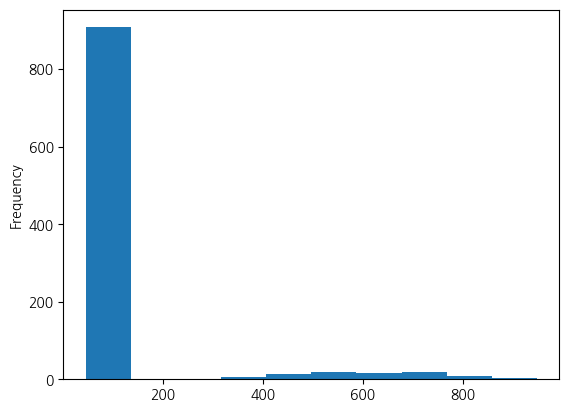

In [104]:
amt_desc['mean'].plot(kind='hist')

In [105]:
amt_desc.columns

Index(['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max'], dtype='object')

In [106]:
amt_desc['75%'] + (1.5 * (amt_desc['75%']-amt_desc['25%']))

cc_num
60416207185            170.66625
60422928733            204.10000
60423098130            175.48625
60427851591            159.06500
60487002085            164.99500
                         ...    
4958589671582726883    197.89250
4973530368125489546    206.69750
4980323467523543940    195.94625
4989847570577635369    249.95250
4992346398065154184    193.88125
Length: 999, dtype: float64

In [107]:
amt_desc['IQR_max'] = amt_desc['75%'] + (1.5 * (amt_desc['75%']-amt_desc['25%']))

In [108]:
amt_desc

,count,mean,std,min,25%,50%,75%,max,IQR_max
cc_num,,,,,,,,,
60416207185,2196.0,59.257796,142.869746,1.02,7.5600,36.540,72.8025,3437.46,170.66625
60422928733,2200.0,65.483159,92.042844,1.01,9.0750,51.405,87.0850,1290.37,204.10000
60423098130,738.0,96.376084,1000.693872,1.01,8.7800,35.425,75.4625,27119.77,175.48625
60427851591,743.0,107.487550,131.014534,8.86,59.1400,76.670,99.1100,1164.36,159.06500
60487002085,735.0,64.096925,153.207660,1.02,8.0950,35.670,70.8550,2758.46,164.99500
...,...,...,...,...,...,...,...,...,...
4958589671582726883,2191.0,67.205600,137.504101,1.00,8.8300,50.130,84.4550,4292.86,197.89250
4973530368125489546,1467.0,75.789148,258.847061,1.01,9.4350,52.660,88.3400,8749.44,206.69750
4980323467523543940,736.0,70.709484,119.903167,1.01,8.4650,42.515,83.4575,1327.43,195.94625


In [109]:
len(amt_desc)

999

In [110]:
# max 값과 4분위수를 이용한 이상치 탐지는 의미가 없어 보임, 개별값 분석 필요
(amt_desc['max'] > amt_desc['IQR_max']).sum()

np.int64(913)

* groupby 연산으로 통해 나온 값 중 mean, std, IQR_max 만 원래 컬럼에 합치기

In [111]:
amt_desc = amt_desc.reset_index()
amt_desc

,cc_num,count,mean,std,min,25%,50%,75%,max,IQR_max
0,60416207185,2196.0,59.257796,142.869746,1.02,7.5600,36.540,72.8025,3437.46,170.66625
1,60422928733,2200.0,65.483159,92.042844,1.01,9.0750,51.405,87.0850,1290.37,204.10000
2,60423098130,738.0,96.376084,1000.693872,1.01,8.7800,35.425,75.4625,27119.77,175.48625
3,60427851591,743.0,107.487550,131.014534,8.86,59.1400,76.670,99.1100,1164.36,159.06500
4,60487002085,735.0,64.096925,153.207660,1.02,8.0950,35.670,70.8550,2758.46,164.99500
...,...,...,...,...,...,...,...,...,...,...
994,4958589671582726883,2191.0,67.205600,137.504101,1.00,8.8300,50.130,84.4550,4292.86,197.89250
995,4973530368125489546,1467.0,75.789148,258.847061,1.01,9.4350,52.660,88.3400,8749.44,206.69750
996,4980323467523543940,736.0,70.709484,119.903167,1.01,8.4650,42.515,83.4575,1327.43,195.94625
997,4989847570577635369,1471.0,93.008939,128.396760,1.03,19.9400,57.170,111.9450,1223.85,249.95250


In [112]:
amt_desc.columns

Index(['cc_num', 'count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max',
       'IQR_max'],
      dtype='object')

In [113]:
data = pd.merge(data, amt_desc[['cc_num', 'mean', 'std', 'IQR_max']], how='left', on='cc_num')
data

,trans_date_trans_time,cc_num,merchant,category,amt,gender,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud,mean,std,IQR_max
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,36.011293,-82.048315,0,89.408743,127.530101,256.62000
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,49.159047,-118.186462,0,56.078113,159.201852,158.06000
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,43.150704,-112.154481,0,69.924272,116.688602,210.80000
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,46.2306,-112.1138,1939,Patent attorney,1967-01-12,47.034331,-112.561071,0,80.090040,280.077880,193.09750
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,38.674999,-78.632459,0,95.341146,94.322842,149.97375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,M,40.4931,-91.8912,519,Town planner,1966-02-13,39.946837,-91.333331,0,62.347968,110.821153,182.53500
1852390,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,M,29.0393,-95.4401,28739,Futures trader,1999-12-27,29.661049,-96.186633,0,50.452289,168.361122,136.04500
1852391,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,F,46.1966,-118.9017,3684,Musician,1981-11-29,46.658340,-119.715054,0,88.704297,119.948793,261.54750
1852392,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,M,44.6255,-116.4493,129,Cartographer,1965-12-15,44.470525,-117.080888,0,60.998052,89.525640,186.94000


In [114]:
data = data.rename(columns=dict(mean='amt_mean', std='amt_std', IQR_max='amt_IQR_max'))
data

,trans_date_trans_time,cc_num,merchant,category,amt,gender,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud,amt_mean,amt_std,amt_IQR_max
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,36.011293,-82.048315,0,89.408743,127.530101,256.62000
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,49.159047,-118.186462,0,56.078113,159.201852,158.06000
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,43.150704,-112.154481,0,69.924272,116.688602,210.80000
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,46.2306,-112.1138,1939,Patent attorney,1967-01-12,47.034331,-112.561071,0,80.090040,280.077880,193.09750
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,38.674999,-78.632459,0,95.341146,94.322842,149.97375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,M,40.4931,-91.8912,519,Town planner,1966-02-13,39.946837,-91.333331,0,62.347968,110.821153,182.53500
1852390,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,M,29.0393,-95.4401,28739,Futures trader,1999-12-27,29.661049,-96.186633,0,50.452289,168.361122,136.04500
1852391,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,F,46.1966,-118.9017,3684,Musician,1981-11-29,46.658340,-119.715054,0,88.704297,119.948793,261.54750
1852392,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,M,44.6255,-116.4493,129,Cartographer,1965-12-15,44.470525,-117.080888,0,60.998052,89.525640,186.94000


In [115]:
(data['amt'] > data['amt_IQR_max']).sum()

np.int64(78516)

In [116]:
# amt_IQR_max 로는 사기건을 찾기 어려움
data[data['amt'] > data['amt_IQR_max']]['is_fraud'].value_counts()

is_fraud
0    71986
1     6530
Name: count, dtype: int64

In [117]:
6530 / (6530+71986)

0.08316776198481839

* 거래 금액의 Z-score를 만들어 찾기
* z-score: (값-평균) / 표준편차

In [118]:
data['amt_zscore'] = (data['amt'] - data['amt_mean']) / data['amt_std']

In [119]:
data

,trans_date_trans_time,cc_num,merchant,category,amt,gender,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud,amt_mean,amt_std,amt_IQR_max,amt_zscore
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,36.011293,-82.048315,0,89.408743,127.530101,256.62000,-0.662108
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,49.159047,-118.186462,0,56.078113,159.201852,158.06000,0.321302
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,43.150704,-112.154481,0,69.924272,116.688602,210.80000,1.287064
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,46.2306,-112.1138,1939,Patent attorney,1967-01-12,47.034331,-112.561071,0,80.090040,280.077880,193.09750,-0.125287
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,38.674999,-78.632459,0,95.341146,94.322842,149.97375,-0.565941
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,M,40.4931,-91.8912,519,Town planner,1966-02-13,39.946837,-91.333331,0,62.347968,110.821153,182.53500,-0.167639
1852390,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,M,29.0393,-95.4401,28739,Futures trader,1999-12-27,29.661049,-96.186633,0,50.452289,168.361122,136.04500,0.364619
1852391,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,F,46.1966,-118.9017,3684,Musician,1981-11-29,46.658340,-119.715054,0,88.704297,119.948793,261.54750,-0.015209
1852392,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,M,44.6255,-116.4493,129,Cartographer,1965-12-15,44.470525,-117.080888,0,60.998052,89.525640,186.94000,-0.592099


In [120]:
data[(data['amt_zscore'] < -3) | (data['amt_zscore'] > 3)]['is_fraud'].value_counts()

is_fraud
0    21725
1     4092
Name: count, dtype: int64

In [121]:
4092 / (4092+21725)

0.15850021303792075

# 사람의 지출 성향은 거의 일정하므로 카테고리별 지출액 분석

In [122]:
cat_amt = data.groupby(['cc_num', 'category'])['amt'].agg(['mean', 'std'])

In [123]:
cat_amt.reset_index()

,cc_num,category,mean,std
0,60416207185,entertainment,51.838855,65.485714
1,60416207185,food_dining,26.737097,46.382603
2,60416207185,gas_transport,59.779429,15.758267
3,60416207185,grocery_net,52.152973,17.694871
4,60416207185,grocery_pos,101.557761,21.894156
...,...,...,...,...
13166,4992346398065154184,misc_pos,60.003043,167.226191
13167,4992346398065154184,personal_care,48.777227,49.523818
13168,4992346398065154184,shopping_net,86.280136,217.047242
13169,4992346398065154184,shopping_pos,64.213333,169.239073


In [124]:
cat_amt = cat_amt.reset_index()

In [125]:
cat_amt.columns = ['cc_num', 'category', 'cat_amt_mean', 'cat_amt_std']
cat_amt

,cc_num,category,cat_amt_mean,cat_amt_std
0,60416207185,entertainment,51.838855,65.485714
1,60416207185,food_dining,26.737097,46.382603
2,60416207185,gas_transport,59.779429,15.758267
3,60416207185,grocery_net,52.152973,17.694871
4,60416207185,grocery_pos,101.557761,21.894156
...,...,...,...,...
13166,4992346398065154184,misc_pos,60.003043,167.226191
13167,4992346398065154184,personal_care,48.777227,49.523818
13168,4992346398065154184,shopping_net,86.280136,217.047242
13169,4992346398065154184,shopping_pos,64.213333,169.239073


In [126]:
data = pd.merge(data, cat_amt, how='left', on=['cc_num', 'category'])
data

,trans_date_trans_time,cc_num,merchant,category,amt,gender,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud,amt_mean,amt_std,amt_IQR_max,amt_zscore,cat_amt_mean,cat_amt_std
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,36.011293,-82.048315,0,89.408743,127.530101,256.62000,-0.662108,84.860809,116.070300
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,49.159047,-118.186462,0,56.078113,159.201852,158.06000,0.321302,99.637224,23.904424
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,43.150704,-112.154481,0,69.924272,116.688602,210.80000,1.287064,46.653103,60.385161
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,46.2306,-112.1138,1939,Patent attorney,1967-01-12,47.034331,-112.561071,0,80.090040,280.077880,193.09750,-0.125287,61.537283,15.746841
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,38.674999,-78.632459,0,95.341146,94.322842,149.97375,-0.565941,35.481357,4.934731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,M,40.4931,-91.8912,519,Town planner,1966-02-13,39.946837,-91.333331,0,62.347968,110.821153,182.53500,-0.167639,45.930979,45.150024
1852390,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,M,29.0393,-95.4401,28739,Futures trader,1999-12-27,29.661049,-96.186633,0,50.452289,168.361122,136.04500,0.364619,50.923503,52.341751
1852391,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,F,46.1966,-118.9017,3684,Musician,1981-11-29,46.658340,-119.715054,0,88.704297,119.948793,261.54750,-0.015209,63.856707,52.309370
1852392,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,M,44.6255,-116.4493,129,Cartographer,1965-12-15,44.470525,-117.080888,0,60.998052,89.525640,186.94000,-0.592099,8.192245,27.244418


In [127]:
data.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'gender', 'lat', 'long', 'city_pop', 'job', 'dob', 'merch_lat',
       'merch_long', 'is_fraud', 'amt_mean', 'amt_std', 'amt_IQR_max',
       'amt_zscore', 'cat_amt_mean', 'cat_amt_std'],
      dtype='object')

In [128]:
data['cat_amt_zscore'] = (data['amt'] - data['cat_amt_mean']) / data['cat_amt_std']
data

,trans_date_trans_time,cc_num,merchant,category,amt,gender,lat,long,city_pop,job,...,merch_lat,merch_long,is_fraud,amt_mean,amt_std,amt_IQR_max,amt_zscore,cat_amt_mean,cat_amt_std,cat_amt_zscore
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,36.0788,-81.1781,3495,"Psychologist, counselling",...,36.011293,-82.048315,0,89.408743,127.530101,256.62000,-0.662108,84.860809,116.070300,-0.688297
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,48.8878,-118.2105,149,Special educational needs teacher,...,49.159047,-118.186462,0,56.078113,159.201852,158.06000,0.321302,99.637224,23.904424,0.317631
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,42.1808,-112.2620,4154,Nature conservation officer,...,43.150704,-112.154481,0,69.924272,116.688602,210.80000,1.287064,46.653103,60.385161,2.872509
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,46.2306,-112.1138,1939,Patent attorney,...,47.034331,-112.561071,0,80.090040,280.077880,193.09750,-0.125287,61.537283,15.746841,-1.050197
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,38.4207,-79.4629,99,Dance movement psychotherapist,...,38.674999,-78.632459,0,95.341146,94.322842,149.97375,-0.565941,35.481357,4.934731,1.312866
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,M,40.4931,-91.8912,519,Town planner,...,39.946837,-91.333331,0,62.347968,110.821153,182.53500,-0.167639,45.930979,45.150024,-0.047862
1852390,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,M,29.0393,-95.4401,28739,Futures trader,...,29.661049,-96.186633,0,50.452289,168.361122,136.04500,0.364619,50.923503,52.341751,1.163822
1852391,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,F,46.1966,-118.9017,3684,Musician,...,46.658340,-119.715054,0,88.704297,119.948793,261.54750,-0.015209,63.856707,52.309370,0.440137
1852392,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,M,44.6255,-116.4493,129,Cartographer,...,44.470525,-117.080888,0,60.998052,89.525640,186.94000,-0.592099,8.192245,27.244418,-0.007423


In [129]:
data[(data['cat_amt_zscore'] < -3) | (data['cat_amt_zscore'] > 3)]['is_fraud'].value_counts()

is_fraud
0    25814
1     6170
Name: count, dtype: int64

In [130]:
6170 / (6170+25814)

0.19290895447723863

# 거주지와 사용 가게와의 거리 계산 및 이상치 탐지

In [131]:
data.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'gender', 'lat', 'long', 'city_pop', 'job', 'dob', 'merch_lat',
       'merch_long', 'is_fraud', 'amt_mean', 'amt_std', 'amt_IQR_max',
       'amt_zscore', 'cat_amt_mean', 'cat_amt_std', 'cat_amt_zscore'],
      dtype='object')

In [132]:
from geopy.distance import distance

In [133]:
home = data[['lat', 'long', 'merch_lat', 'merch_long']]

In [134]:
home

,lat,long,merch_lat,merch_long
0,36.0788,-81.1781,36.011293,-82.048315
1,48.8878,-118.2105,49.159047,-118.186462
2,42.1808,-112.2620,43.150704,-112.154481
3,46.2306,-112.1138,47.034331,-112.561071
4,38.4207,-79.4629,38.674999,-78.632459
...,...,...,...,...
1852389,40.4931,-91.8912,39.946837,-91.333331
1852390,29.0393,-95.4401,29.661049,-96.186633
1852391,46.1966,-118.9017,46.658340,-119.715054
1852392,44.6255,-116.4493,44.470525,-117.080888


In [135]:
%%time
data['home_merch_dist']= data.apply(lambda x: distance((x['lat'], x['long']), (x['merch_lat'], x['merch_long'])).km, axis=1)

CPU times: total: 11min 21s
Wall time: 11min 45s


In [136]:
data

,trans_date_trans_time,cc_num,merchant,category,amt,gender,lat,long,city_pop,job,...,merch_long,is_fraud,amt_mean,amt_std,amt_IQR_max,amt_zscore,cat_amt_mean,cat_amt_std,cat_amt_zscore,home_merch_dist
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,36.0788,-81.1781,3495,"Psychologist, counselling",...,-82.048315,0,89.408743,127.530101,256.62000,-0.662108,84.860809,116.070300,-0.688297,78.773821
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,48.8878,-118.2105,149,Special educational needs teacher,...,-118.186462,0,56.078113,159.201852,158.06000,0.321302,99.637224,23.904424,0.317631,30.216618
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,42.1808,-112.2620,4154,Nature conservation officer,...,-112.154481,0,69.924272,116.688602,210.80000,1.287064,46.653103,60.385161,2.872509,108.102912
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,46.2306,-112.1138,1939,Patent attorney,...,-112.561071,0,80.090040,280.077880,193.09750,-0.125287,61.537283,15.746841,-1.050197,95.685115
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,38.4207,-79.4629,99,Dance movement psychotherapist,...,-78.632459,0,95.341146,94.322842,149.97375,-0.565941,35.481357,4.934731,1.312866,77.702395
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,M,40.4931,-91.8912,519,Town planner,...,-91.333331,0,62.347968,110.821153,182.53500,-0.167639,45.930979,45.150024,-0.047862,77.032467
1852390,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,M,29.0393,-95.4401,28739,Futures trader,...,-96.186633,0,50.452289,168.361122,136.04500,0.364619,50.923503,52.341751,1.163822,100.023736
1852391,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,F,46.1966,-118.9017,3684,Musician,...,-119.715054,0,88.704297,119.948793,261.54750,-0.015209,63.856707,52.309370,0.440137,80.887812
1852392,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,M,44.6255,-116.4493,129,Cartographer,...,-117.080888,0,60.998052,89.525640,186.94000,-0.592099,8.192245,27.244418,-0.007423,53.060882


사용자별 평균 거래처 거리를 측정 후 z-score를 구해 그 범위를 벗어나는지 확인

In [137]:
dist_mean_std = data.groupby('cc_num')['home_merch_dist'].agg(['mean','std'])
dist_mean_std.columns = ['dist_mean', 'dist_std']
dist_mean_std = dist_mean_std.reset_index()
dist_mean_std

,cc_num,dist_mean,dist_std
0,60416207185,73.534542,28.698149
1,60422928733,78.986422,29.299240
2,60423098130,77.826916,28.187560
3,60427851591,75.711544,28.977432
4,60487002085,79.442907,28.767086
...,...,...,...
994,4958589671582726883,76.735763,29.123745
995,4973530368125489546,78.753844,29.450837
996,4980323467523543940,72.272008,28.279840
997,4989847570577635369,76.969707,29.386961


In [138]:
data = pd.merge(data, dist_mean_std, how='left', on='cc_num')
data

,trans_date_trans_time,cc_num,merchant,category,amt,gender,lat,long,city_pop,job,...,amt_mean,amt_std,amt_IQR_max,amt_zscore,cat_amt_mean,cat_amt_std,cat_amt_zscore,home_merch_dist,dist_mean,dist_std
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,36.0788,-81.1781,3495,"Psychologist, counselling",...,89.408743,127.530101,256.62000,-0.662108,84.860809,116.070300,-0.688297,78.773821,77.842362,30.072493
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,48.8878,-118.2105,149,Special educational needs teacher,...,56.078113,159.201852,158.06000,0.321302,99.637224,23.904424,0.317631,30.216618,71.656621,28.090646
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,42.1808,-112.2620,4154,Nature conservation officer,...,69.924272,116.688602,210.80000,1.287064,46.653103,60.385161,2.872509,108.102912,74.581011,28.883956
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,46.2306,-112.1138,1939,Patent attorney,...,80.090040,280.077880,193.09750,-0.125287,61.537283,15.746841,-1.050197,95.685115,72.049339,28.892378
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,38.4207,-79.4629,99,Dance movement psychotherapist,...,95.341146,94.322842,149.97375,-0.565941,35.481357,4.934731,1.312866,77.702395,75.835518,29.153167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,M,40.4931,-91.8912,519,Town planner,...,62.347968,110.821153,182.53500,-0.167639,45.930979,45.150024,-0.047862,77.032467,75.524271,28.958817
1852390,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,M,29.0393,-95.4401,28739,Futures trader,...,50.452289,168.361122,136.04500,0.364619,50.923503,52.341751,1.163822,100.023736,79.172599,30.051452
1852391,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,F,46.1966,-118.9017,3684,Musician,...,88.704297,119.948793,261.54750,-0.015209,63.856707,52.309370,0.440137,80.887812,72.656420,28.552151
1852392,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,M,44.6255,-116.4493,129,Cartographer,...,60.998052,89.525640,186.94000,-0.592099,8.192245,27.244418,-0.007423,53.060882,73.688955,28.255280


In [139]:
data['dist_zscore'] = (data['home_merch_dist'] -  data['dist_mean']) / data['dist_std']

In [140]:
data

,trans_date_trans_time,cc_num,merchant,category,amt,gender,lat,long,city_pop,job,...,amt_std,amt_IQR_max,amt_zscore,cat_amt_mean,cat_amt_std,cat_amt_zscore,home_merch_dist,dist_mean,dist_std,dist_zscore
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,36.0788,-81.1781,3495,"Psychologist, counselling",...,127.530101,256.62000,-0.662108,84.860809,116.070300,-0.688297,78.773821,77.842362,30.072493,0.030974
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,48.8878,-118.2105,149,Special educational needs teacher,...,159.201852,158.06000,0.321302,99.637224,23.904424,0.317631,30.216618,71.656621,28.090646,-1.475224
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,42.1808,-112.2620,4154,Nature conservation officer,...,116.688602,210.80000,1.287064,46.653103,60.385161,2.872509,108.102912,74.581011,28.883956,1.160572
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,46.2306,-112.1138,1939,Patent attorney,...,280.077880,193.09750,-0.125287,61.537283,15.746841,-1.050197,95.685115,72.049339,28.892378,0.818063
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,38.4207,-79.4629,99,Dance movement psychotherapist,...,94.322842,149.97375,-0.565941,35.481357,4.934731,1.312866,77.702395,75.835518,29.153167,0.064037
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,M,40.4931,-91.8912,519,Town planner,...,110.821153,182.53500,-0.167639,45.930979,45.150024,-0.047862,77.032467,75.524271,28.958817,0.052081
1852390,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,M,29.0393,-95.4401,28739,Futures trader,...,168.361122,136.04500,0.364619,50.923503,52.341751,1.163822,100.023736,79.172599,30.051452,0.693848
1852391,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,F,46.1966,-118.9017,3684,Musician,...,119.948793,261.54750,-0.015209,63.856707,52.309370,0.440137,80.887812,72.656420,28.552151,0.288293
1852392,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,M,44.6255,-116.4493,129,Cartographer,...,89.525640,186.94000,-0.592099,8.192245,27.244418,-0.007423,53.060882,73.688955,28.255280,-0.730061


In [141]:
data[(data['dist_zscore'] < -3) | (data['dist_zscore'] > 3)]

,trans_date_trans_time,cc_num,merchant,category,amt,gender,lat,long,city_pop,job,...,amt_std,amt_IQR_max,amt_zscore,cat_amt_mean,cat_amt_std,cat_amt_zscore,home_merch_dist,dist_mean,dist_std,dist_zscore


In [142]:
data[(data['dist_zscore'] < -3) | (data['dist_zscore'] > 3)]['is_fraud'].value_counts()

Series([], Name: count, dtype: int64)

In [143]:
data.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'gender', 'lat', 'long', 'city_pop', 'job', 'dob', 'merch_lat',
       'merch_long', 'is_fraud', 'amt_mean', 'amt_std', 'amt_IQR_max',
       'amt_zscore', 'cat_amt_mean', 'cat_amt_std', 'cat_amt_zscore',
       'home_merch_dist', 'dist_mean', 'dist_std', 'dist_zscore'],
      dtype='object')

* 불필요한 컬럼 제거하기

In [144]:
data2 = data.copy()

In [145]:
data = data.drop(['trans_date_trans_time', 'cc_num', 'lat', 'long', 'merch_lat',
       'merch_long', 'amt_mean', 'amt_std', 'cat_amt_mean', 'cat_amt_std',
       'dist_mean', 'dist_std'], axis=1)
data

,merchant,category,amt,gender,city_pop,job,dob,is_fraud,amt_IQR_max,amt_zscore,cat_amt_zscore,home_merch_dist,dist_zscore
0,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,3495,"Psychologist, counselling",1988-03-09,0,256.62000,-0.662108,-0.688297,78.773821,0.030974
1,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,149,Special educational needs teacher,1978-06-21,0,158.06000,0.321302,0.317631,30.216618,-1.475224
2,fraud_Lind-Buckridge,entertainment,220.11,M,4154,Nature conservation officer,1962-01-19,0,210.80000,1.287064,2.872509,108.102912,1.160572
3,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,1939,Patent attorney,1967-01-12,0,193.09750,-0.125287,-1.050197,95.685115,0.818063
4,fraud_Keeling-Crist,misc_pos,41.96,M,99,Dance movement psychotherapist,1986-03-28,0,149.97375,-0.565941,1.312866,77.702395,0.064037
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,fraud_Reilly and Sons,health_fitness,43.77,M,519,Town planner,1966-02-13,0,182.53500,-0.167639,-0.047862,77.032467,0.052081
1852390,fraud_Hoppe-Parisian,kids_pets,111.84,M,28739,Futures trader,1999-12-27,0,136.04500,0.364619,1.163822,100.023736,0.693848
1852391,fraud_Rau-Robel,kids_pets,86.88,F,3684,Musician,1981-11-29,0,261.54750,-0.015209,0.440137,80.887812,0.288293
1852392,fraud_Breitenberg LLC,travel,7.99,M,129,Cartographer,1965-12-15,0,186.94000,-0.592099,-0.007423,53.060882,-0.730061


In [146]:
data['age'] = data['dob'].apply(lambda x: 2020 - int(x[:4]))

<Axes: ylabel='Frequency'>

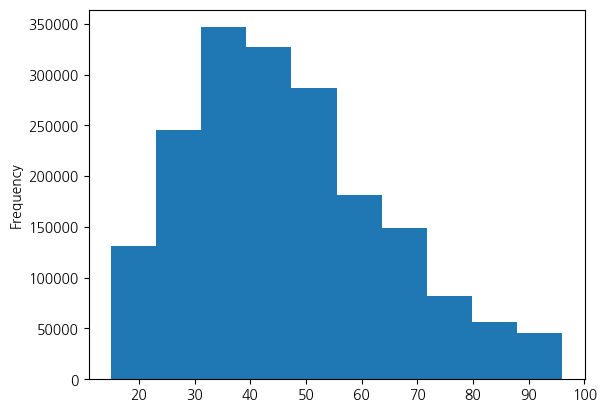

In [147]:
data['age'].plot(kind='hist')

In [148]:
data.groupby('age')['is_fraud'].mean().sort_values(ascending=False)

age
18    1.000000
95    1.000000
88    0.016189
77    0.011813
80    0.011646
        ...   
35    0.003262
36    0.003248
45    0.003224
16    0.002918
15    0.002396
Name: is_fraud, Length: 82, dtype: float64

In [149]:
data['age'].value_counts()

age
48    65036
36    56964
33    53377
35    53335
46    48984
      ...  
88     2965
15     2922
96      735
18       12
95       11
Name: count, Length: 82, dtype: int64

In [150]:
X = data.drop('is_fraud', axis=1)
y = data['is_fraud']

In [151]:
X = pd.get_dummies(X, drop_first=True)

In [152]:
y.value_counts()

is_fraud
0    1842743
1       9651
Name: count, dtype: int64

In [153]:
9651 / (9651+1842743)

0.005210014716091717

In [154]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearnex import patch_sklearn
patch_sklearn()
import gc

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [155]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_valid, y_valid, test_size=0.5, stratify=y_valid, random_state=42)

In [156]:
print(len(X_train), len(X_valid), len(X_test))

1111436 370479 370479


In [107]:
dtc = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dtc.fit(X_train, y_train)
pred = dtc.predict(X_valid)
print(classification_report(y_valid, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    368549
           1       0.54      0.65      0.59      1930

    accuracy                           1.00    370479
   macro avg       0.77      0.83      0.79    370479
weighted avg       1.00      1.00      1.00    370479



In [112]:
rfc = RandomForestClassifier(class_weight='balanced', n_jobs=12, random_state=42)
rfc.fit(X_train, y_train)
pred = rfc.predict(X_valid)
print(classification_report(y_valid, pred))
print("=" *30, "Test Score", "=" *30)
pred_test = rfc.predict(X_test)
print(classification_report(y_test, pred_test), end="\n\n")
unreachable_objects = gc.collect()
print(f"수거된 객체 수: {unreachable_objects}")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    368549
           1       0.84      0.63      0.72      1930

    accuracy                           1.00    370479
   macro avg       0.92      0.82      0.86    370479
weighted avg       1.00      1.00      1.00    370479

============================== Test Score ==============================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    368549
           1       0.87      0.64      0.74      1930

    accuracy                           1.00    370479
   macro avg       0.93      0.82      0.87    370479
weighted avg       1.00      1.00      1.00    370479


수거된 객체 수: 5631


In [ ]:
xgb = XGBClassifier(n_jobs=12, random_state=42)
xgb.fit(X_train, y_train)
pred = xgb.predict(X_valid)
print(classification_report(y_valid, pred))
print("=" *30, "Test Score", "=" *30)
pred_test = rfc.predict(X_test)
print(classification_report(y_test, pred_test), end="\n\n")

In [157]:
xgb = XGBClassifier(n_jobs=12, random_state=42)

In [160]:
xgb_params = dict(n_estimators=[100, 500, 1000],
                 max_depth=[1, 5, 10, 15, 20],
                 learning_rate=[0.1, 0.5, 1],
                 booster=['gbtree', 'dart'],
                 scale_pos_weight=[0, 3],
                 )

In [161]:
rand_cv = RandomizedSearchCV(xgb, param_distributions=xgb_params,
                            cv=3, scoring='roc_auc', random_state=10)
rand_cv.fit(X_train, y_train)
pred = rand_cv.predict(X_test)
print("best_params: ", rand_cv.best_params_)
print("best_score_: ", rand_cv.best_score_)

KeyboardInterrupt: 

In [108]:
lgbm = LGBMClassifier(n_jobs=12, random_state=42)
lgbm.fit(X_train, y_train)
pred = lgbm.predict(X_valid)
print(classification_report(y_valid, pred))
print("=" *30, "Test Score", "=" *30)
pred_test = rfc.predict(X_test)
print(classification_report(y_test, pred_test), end="\n\n")

C:\Users\haram\miniforge3\envs\fintech\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 지정된 파일을 찾을 수 없습니다
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\haram\miniforge3\envs\fintech\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Users\haram\miniforge3\envs\fintech\lib\subprocess.py", line 505, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\haram\miniforge3\envs\fintech\lib\subprocess.py", line 951, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\haram\miniforge3\envs\fintech\lib\subprocess.py", line 1436, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


LightGBMError: Do not support special JSON characters in feature name.

In [ ]:
cbc = CatBoostClassifier(random_state=42)
cbc.fit(X_train, y_train)
pred = cbc.predict(X_valid)
print(classification_report(y_valid, pred))
print("=" *30, "Test Score", "=" *30)
pred_test = rfc.predict(X_test)
print(classification_report(y_test, pred_test), end="\n\n")